In [ ]:
import sinter
import stim
from typing import List
import matplotlib.pyplot as plt

In [2]:
noise = [0.01, 0.05, 0.08, 0.09, 0.1, 0.2]
code_distance = [3, 5, 7, 9]
MAX_SHOTS = 100000
MAX_ERRORS = 1000

In [8]:
# `rotated_memory_x` (surface_code):
# Initialize a logical `|+>` in a rotated surface code,
# preserve it against noise for the given number of rounds,
# then measure in the X basis.
task_configs = [
    dict(
        circuit=stim.Circuit.generated(
            "surface_code:rotated_memory_x",
            rounds=d * 3,
            distance=d,
            before_round_data_depolarization=p,
            after_clifford_depolarization=p,
        ),
        json_metadata={"d": d, "p": p, "label": "rotated_memory_x"},
    )
    for d in code_distance
    for p in noise
]
tasks = [sinter.Task(**task) for task in task_configs]

pymatching_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=10,
    tasks=tasks,
    decoders=["pymatching"],
    max_shots=MAX_SHOTS,
    max_errors=MAX_ERRORS,
    count_observable_error_combos=True,
    count_detection_events=True,
)

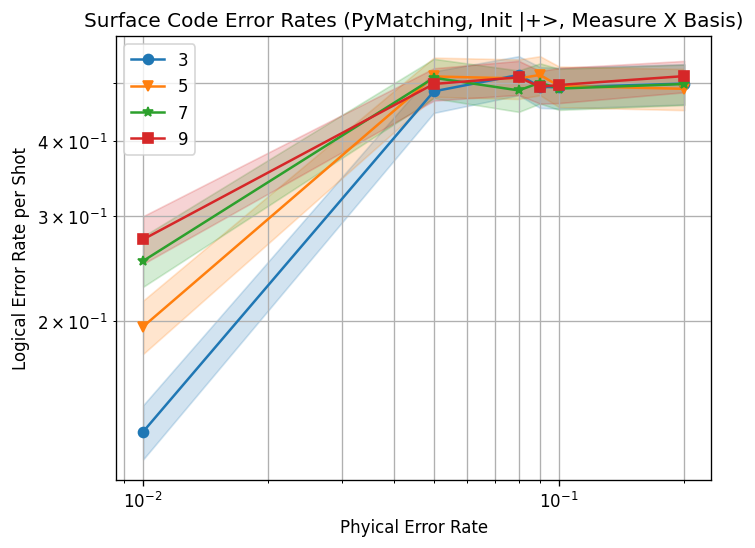

In [10]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=pymatching_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: stats.json_metadata["d"],
)
# ax.set_ylim(1e-6, 1e0)
# ax.set_xlim(1e-2, 2e-1)
ax.loglog()
ax.set_title("Surface Code Error Rates (PyMatching, Init |+>, Measure X Basis)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)

In [ ]:
import sinter
import stim
from typing import List
import matplotlib.pyplot as plt

from util.erasure_converter import convert_circuit_errors_to_erasures_v2
from util.decoder import HeraldedEraseDecoder
from util.sinter_task import TaskConfig

noise = [0.01, 0.05, 0.08, 0.09, 0.1, 0.2]
code_distance = [3, 5, 7, 9]
MAX_SHOTS = 100000
MAX_ERRORS = 1000

task_configs = [
    dict(
        circuit=stim.Circuit.generated(
            "surface_code:rotated_memory_x",
            rounds=d * 2,
            distance=d,
            before_round_data_depolarization=p,
        ),
        json_metadata={"d": d, "p": p, "label": "rotated_memory_x"},
    )
    for d in code_distance
    for p in noise
]

task_configs = [
    dict(
        circuit=convert_circuit_errors_to_erasures_v2(task["circuit"]),
        json_metadata=task["json_metadata"],
    )
    for task in task_configs
]


def build_custom_decoders(task_configs):
    decoder_strs = []
    decoder_dict = {}
    for task in task_configs:
        circuit = task["circuit"]
        decoder_str = f"heralded_erase_{id(circuit)}"
        decoder = HeraldedEraseDecoder(circuit=circuit)
        decoder_strs.append(decoder_str)
        decoder_dict[decoder_str] = decoder
    return decoder_strs, decoder_dict


custom_decoder_strs, custom_decoder_dict = build_custom_decoders(task_configs)

tasks = [sinter.Task(**task) for task in task_configs]

mwpf_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=10,
    tasks=tasks,
    decoders=custom_decoder_strs,
    custom_decoders=custom_decoder_dict,
    max_shots=MAX_SHOTS,
    max_errors=MAX_ERRORS,
    print_progress=True,
    count_observable_error_combos=True,
    count_detection_events=True,
)

TypeError: cannot unpack non-iterable NoneType object